#Classification Task

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, chi2, f_classif

#1. Exploratory Data Analysis and Data Understanding

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/weatherAUS.csv')
print(df.shape)
print(df.head())
print(df.info())
print(df['RainTomorrow'].value_counts(normalize=True))

(145460, 23)
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0    

In [ ]:
df = df.dropna(subset=['RainTomorrow'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   fl

In [ ]:
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes':1, 'No':0})
df['RainTomorrow'].unique()


array([0, 1])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   fl

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.isnull().sum())


Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RainTomorrow         0
dtype: int64


In [ ]:
(1406/142193)*100

0.9887969168665124

In [ ]:
columns = df.columns
for column in columns:
  if df[column].dtype=="object":
    df[column]=df[column].fillna(df[column].mode()[0])
  else:
    df[column]=df[column].fillna(df[column].mean())

In [ ]:
print(df.isnull().sum())


Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64


In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainTomorrow
count,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,0.224181
std,6.388924,7.109554,8.423217,3.168114,2.734927,13.138385,8.851082,8.721551,18.932077,20.532065,6.746248,6.681788,2.278080,2.104709,6.472166,6.870771,0.417043
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,4.000000,7.624853,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.000000,3.000000,4.000000,12.300000,16.700000,0.000000
50%,12.000000,22.700000,0.000000,5.469824,7.624853,39.000000,13.000000,18.637576,70.000000,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.800000,21.300000,0.000000
75%,16.800000,28.200000,0.800000,5.469824,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.300000,0.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,1.000000


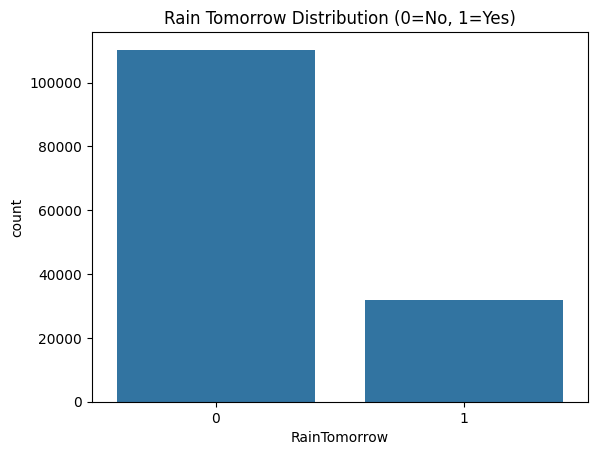

In [ ]:
sns.countplot(x='RainTomorrow', data=df)
plt.title('Rain Tomorrow Distribution (0=No, 1=Yes)')
plt.show()

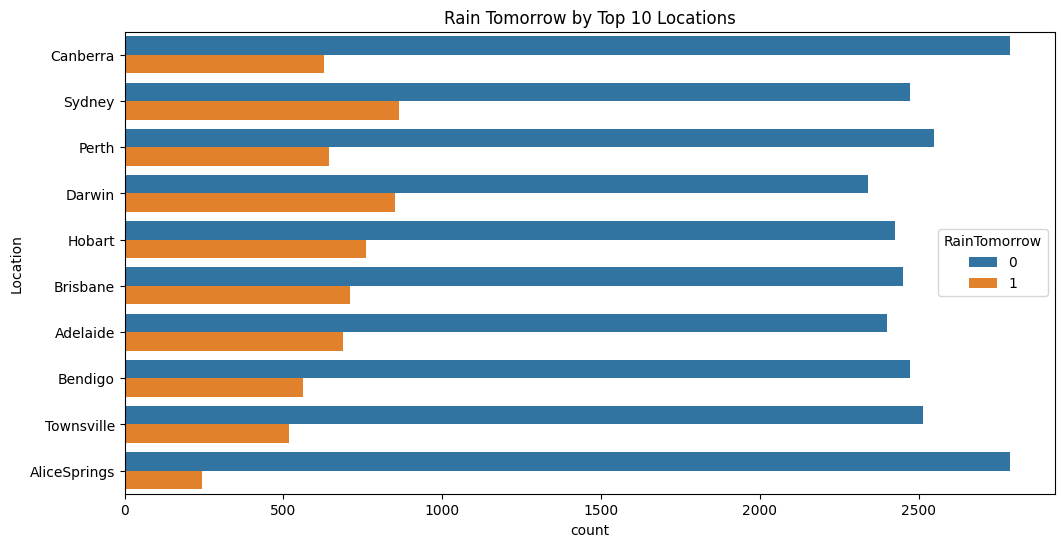

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(y='Location', hue='RainTomorrow', data=df, order=df['Location'].value_counts().index[:10])
plt.title('Rain Tomorrow by Top 10 Locations')
plt.show()

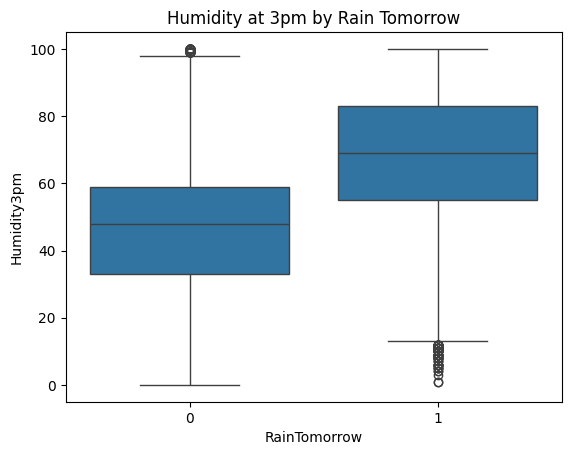

In [ ]:
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.title('Humidity at 3pm by Rain Tomorrow')
plt.show()

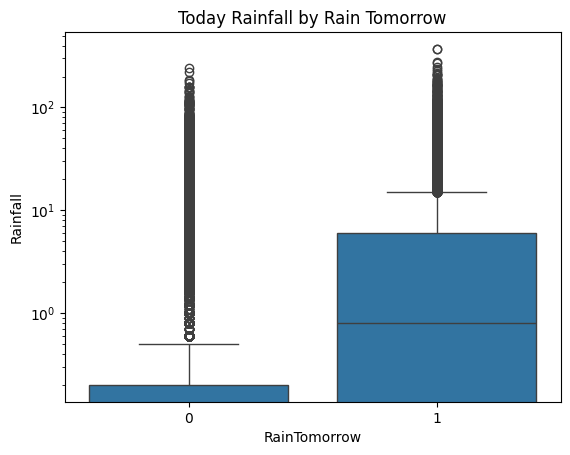

In [ ]:
sns.boxplot(x='RainTomorrow', y='Rainfall', data=df)
plt.yscale('log')  # because skewed
plt.title('Today Rainfall by Rain Tomorrow')
plt.show()

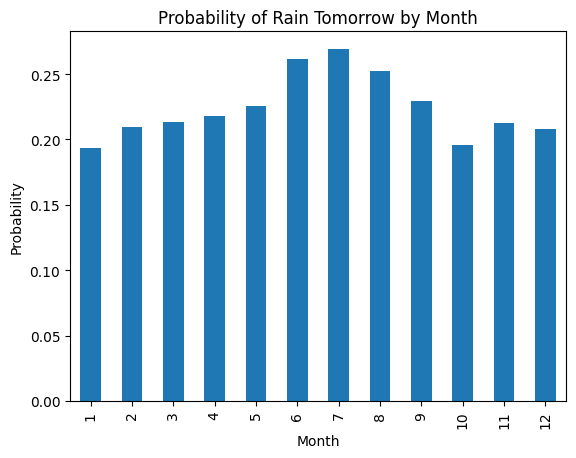

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

monthly_rain = df.groupby('Month')['RainTomorrow'].mean()
monthly_rain.plot(kind='bar')
plt.title('Probability of Rain Tomorrow by Month')
plt.ylabel('Probability')
plt.show()

In [ ]:
print("Final shape ready for modeling:", df.shape)
print("No missing values:", df.isnull().sum().sum() == 0)

Final shape ready for modeling: (142193, 24)
No missing values: True


#2. Build a Neural Network Model

In [ ]:

columns_to_drop = ['Date', 'RISK_MM']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')


X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']


numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("\nShape of X:", X.shape, "| Shape of y:", y.shape)

Numeric features: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical features: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

Shape of X: (142193, 22) | Shape of y: (142193,)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_sample = preprocessor.fit_transform(X.head(1000))
print("Transformed sample shape:", X_sample.shape)

Transformed sample shape: (1000, 67)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))

Train shape: (113754, 22) (113754,)
Test shape: (28439, 22) (28439,)

Train class distribution:
 RainTomorrow
0    0.775814
1    0.224186
Name: proportion, dtype: float64


In [ ]:
mlp_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    ))
])


mlp_pipe.fit(X_train, y_train)

print("Neural Network training completed!")

Neural Network training completed!


Accuracy : 0.861211716305074
Precision (Yes): 0.7564427545416138
Recall (Yes)   : 0.5617254901960784
F1-Score (Yes) : 0.64470249347376
ROC-AUC       : 0.8972068918938134

Classification Report:
               precision    recall  f1-score   support

     No Rain       0.88      0.95      0.91     22064
        Rain       0.76      0.56      0.64      6375

    accuracy                           0.86     28439
   macro avg       0.82      0.75      0.78     28439
weighted avg       0.85      0.86      0.85     28439



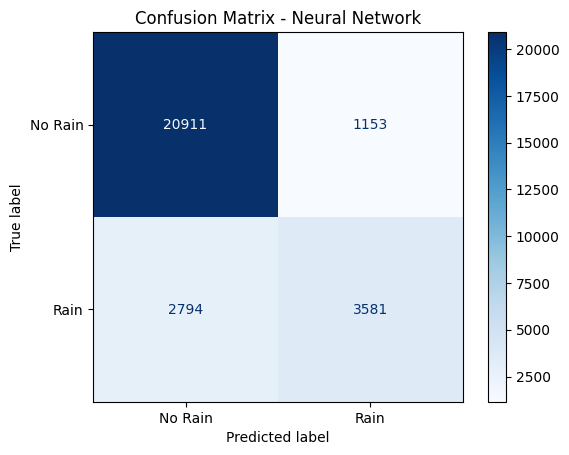

In [ ]:
y_pred = mlp_pipe.predict(X_test)
y_prob = mlp_pipe.predict_proba(X_test)[:, 1]


print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision (Yes):", precision_score(y_test, y_pred))
print("Recall (Yes)   :", recall_score(y_test, y_pred))
print("F1-Score (Yes) :", f1_score(y_test, y_pred))
print("ROC-AUC       :", roc_auc_score(y_test, y_prob))


print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.show()

#3. Build Primary Machine Learning Models

#Model 1: Logistic Regression

Logistic Regression Results:
              precision    recall  f1-score   support

     No Rain       0.93      0.80      0.86     22064
        Rain       0.53      0.78      0.63      6375

    accuracy                           0.79     28439
   macro avg       0.73      0.79      0.74     28439
weighted avg       0.84      0.79      0.81     28439

ROC-AUC: 0.8728457748581666


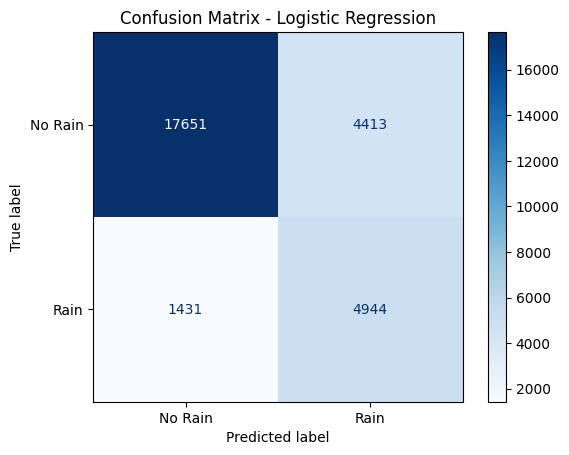

In [ ]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs'
    ))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]


print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr, target_names=['No Rain', 'Rain']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


ConfusionMatrixDisplay.from_estimator(lr_pipe, X_test, y_test, display_labels=['No Rain', 'Rain'], cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

#Model 1: Descision Tree


Decision Tree Results:
              precision    recall  f1-score   support

     No Rain       0.86      0.86      0.86     22064
        Rain       0.53      0.53      0.53      6375

    accuracy                           0.79     28439
   macro avg       0.70      0.70      0.70     28439
weighted avg       0.79      0.79      0.79     28439

ROC-AUC: 0.6950838736509832


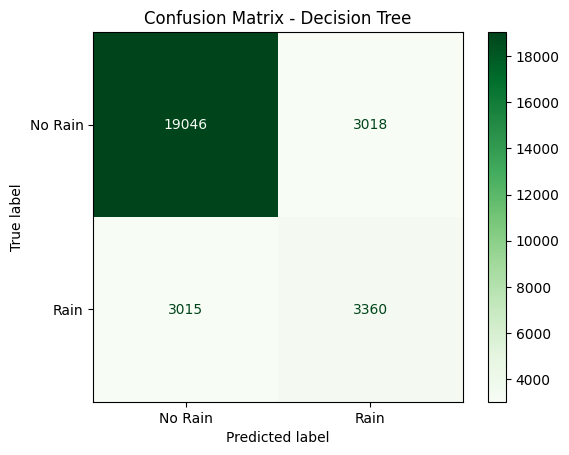

In [ ]:
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:, 1]


print("\nDecision Tree Results:")
print(classification_report(y_test, y_pred_dt, target_names=['No Rain', 'Rain']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))


ConfusionMatrixDisplay.from_estimator(dt_pipe, X_test, y_test, display_labels=['No Rain', 'Rain'], cmap='Greens')
plt.title('Confusion Matrix - Decision Tree')
plt.show()




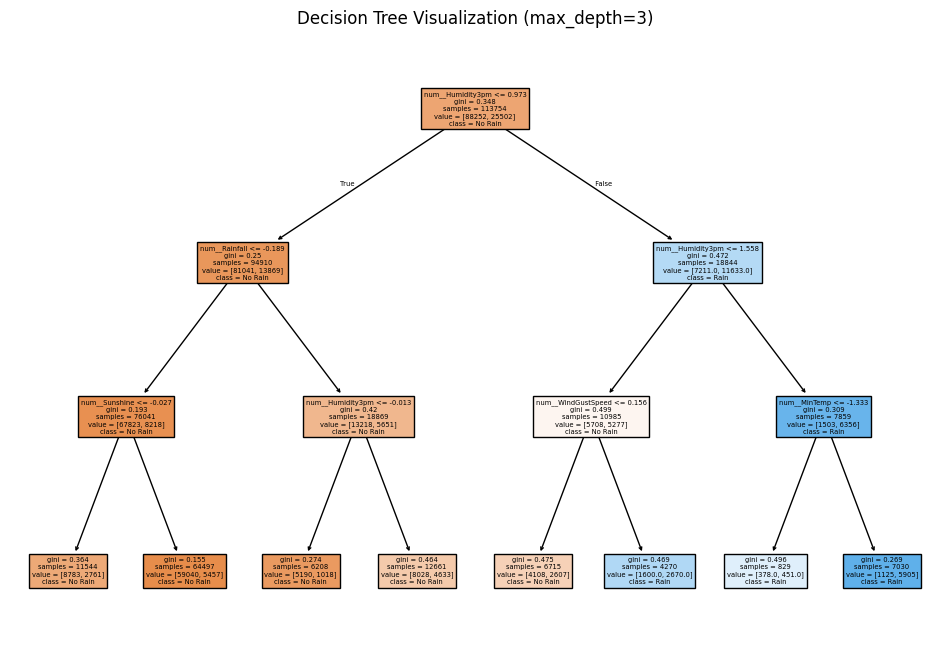

In [ ]:
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(preprocessor.fit_transform(X_train), y_train)
plt.figure(figsize=(12,8))
plot_tree(dt_shallow, feature_names=preprocessor.get_feature_names_out(), class_names=['No Rain', 'Rain'], filled=True)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()

#4. Hyperparameter Optimization with Cross-Validation

In [ ]:
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    lr_pipe,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best params for Logistic:", grid_lr.best_params_)
print("Best CV F1-score:", grid_lr.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params for Logistic: {'classifier__C': 100, 'classifier__solver': 'lbfgs'}
Best CV F1-score: 0.6272445396032397


In [ ]:
param_grid_dt = {
    'classifier__max_depth': [3, 5, 8, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    dt_pipe,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("Best params for Decision Tree:", grid_dt.best_params_)
print("Best CV F1-score:", grid_dt.best_score_)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best params for Decision Tree: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV F1-score: 0.600159930941311


#5. Feature Selection

Selected features: ['num__MaxTemp' 'num__Rainfall' 'num__Evaporation' 'num__Sunshine'
 'num__WindGustSpeed' 'num__WindSpeed9am' 'num__Humidity9am'
 'num__Humidity3pm' 'num__Pressure9am' 'num__Pressure3pm' 'num__Cloud9am'
 'num__Cloud3pm' 'num__Temp3pm' 'cat__RainToday_No' 'cat__RainToday_Yes']
Scores: [ 2983.16522655  6570.81810812   916.81385444 13547.52236746
  6006.16204393   972.31714572  7852.80138312 27128.14161313
  6594.70727431  5515.13334785  7825.55667409 11419.74372376
  4315.87696816 11730.91146789 11730.91146789]


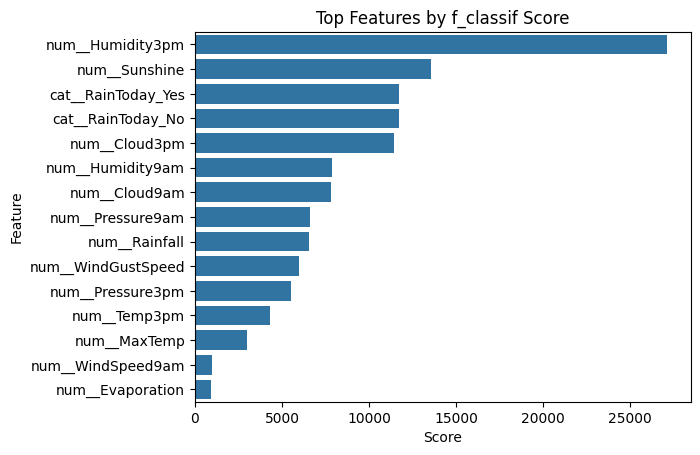

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)


selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X_train_transformed, y_train)


selected_mask = selector.get_support()
feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[selected_mask]

print("Selected features:", selected_features)
print("Scores:", selector.scores_[selected_mask])


scores_df = pd.DataFrame({'Feature': feature_names, 'Score': selector.scores_})
scores_df = scores_df.sort_values('Score', ascending=False).head(15)
sns.barplot(x='Score', y='Feature', data=scores_df)
plt.title('Top Features by f_classif Score')
plt.show()

#6. Final Models and Comparative Analysis

In [ ]:
# Clean dict without prefix
clean_best_lr = {k.replace('classifier__', ''): v for k, v in grid_lr.best_params_.items()}
clean_best_dt = {k.replace('classifier__', ''): v for k, v in grid_dt.best_params_.items()}

print("Clean LR params:", clean_best_lr)
print("Clean DT params:", clean_best_dt)

Clean LR params: {'C': 100, 'solver': 'lbfgs'}
Clean DT params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


Final Logistic:
              precision    recall  f1-score   support

     No Rain       0.87      0.95      0.91     22064
        Rain       0.73      0.51      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439

ROC-AUC: 0.8721404896984173


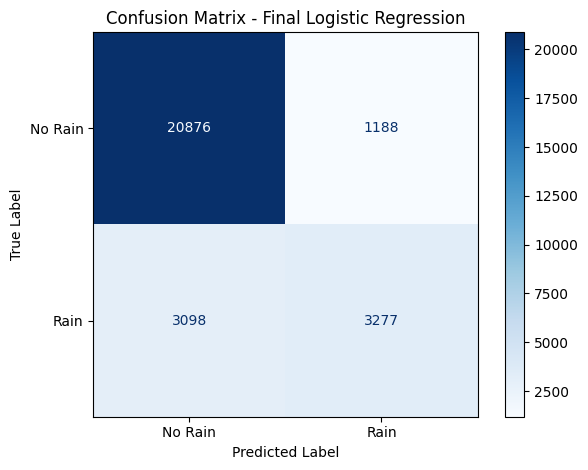

In [ ]:
# Final Logistic Regression
final_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        **clean_best_lr,
        max_iter=2000,
        random_state=42
    ))
])

final_lr.fit(X_train, y_train)

y_pred_flr = final_lr.predict(X_test)
y_prob_flr = final_lr.predict_proba(X_test)[:, 1]

print("Final Logistic:")
print(classification_report(y_test, y_pred_flr, target_names=['No Rain', 'Rain']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_flr))

cm_lr = confusion_matrix(y_test, y_pred_flr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['No Rain', 'Rain']
)

disp_lr.plot(cmap='Blues')
plt.title('Confusion Matrix - Final Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)  # cleaner look
plt.tight_layout()
plt.show()

Final Decision Tree:
              precision    recall  f1-score   support

     No Rain       0.86      0.95      0.90     22064
        Rain       0.72      0.47      0.57      6375

    accuracy                           0.84     28439
   macro avg       0.79      0.71      0.74     28439
weighted avg       0.83      0.84      0.83     28439

ROC-AUC: 0.8456157275092778


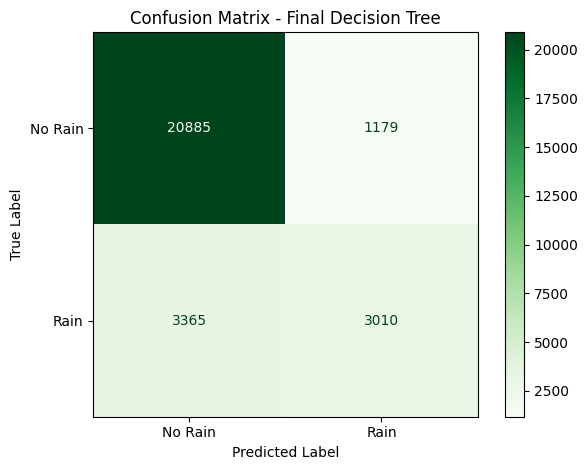

In [ ]:
# Final Decision Tree
final_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        **clean_best_dt,
        random_state=42
    ))
])

final_dt.fit(X_train, y_train)

y_pred_fdt = final_dt.predict(X_test)
y_prob_fdt = final_dt.predict_proba(X_test)[:, 1]

print("Final Decision Tree:")
print(classification_report(y_test, y_pred_fdt, target_names=['No Rain', 'Rain']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_fdt))

cm_dt = confusion_matrix(y_test, y_pred_fdt)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['No Rain', 'Rain']
)

disp_dt.plot(cmap='Greens')
plt.title('Confusion Matrix - Final Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Best Params (cleaned)': [str(clean_best_lr), str(clean_best_dt)],
    'Test Accuracy': [accuracy_score(y_test, y_pred_flr), accuracy_score(y_test, y_pred_fdt)],
    'F1-Score (Rain)': [f1_score(y_test, y_pred_flr), f1_score(y_test, y_pred_fdt)],
    'Recall (Rain)': [recall_score(y_test, y_pred_flr), recall_score(y_test, y_pred_fdt)],
    'Precision (Rain)': [precision_score(y_test, y_pred_flr), precision_score(y_test, y_pred_fdt)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_flr), roc_auc_score(y_test, y_prob_fdt)]
})

print(comparison_df.to_markdown(index=False))
comparison_df.to_csv('/content/drive/My Drive/Colab Notebooks/comparison_table.csv')

| Model               | Best Params (cleaned)                                            |   Test Accuracy |   F1-Score (Rain) |   Recall (Rain) |   Precision (Rain) |   ROC-AUC |
|:--------------------|:-----------------------------------------------------------------|----------------:|------------------:|----------------:|-------------------:|----------:|
| Logistic Regression | {'C': 100, 'solver': 'lbfgs'}                                    |        0.849291 |          0.604613 |        0.514039 |           0.733931 |  0.87214  |
| Decision Tree       | {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2} |        0.840219 |          0.56986  |        0.472157 |           0.718549 |  0.845616 |


In [ ]:
df_comparison = pd.read_csv('/content/drive/My Drive/Colab Notebooks/comparison_table.csv')
df_comparison

,Unnamed: 0,Model,Best Params (cleaned),Test Accuracy,F1-Score (Rain),Recall (Rain),Precision (Rain),ROC-AUC
0,0,Logistic Regression,"{'C': 100, 'solver': 'lbfgs'}",0.849291,0.604613,0.514039,0.733931,0.872140
1,1,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.840219,0.569860,0.472157,0.718549,0.845616
